# Analyse : regression_esserdaoui.py

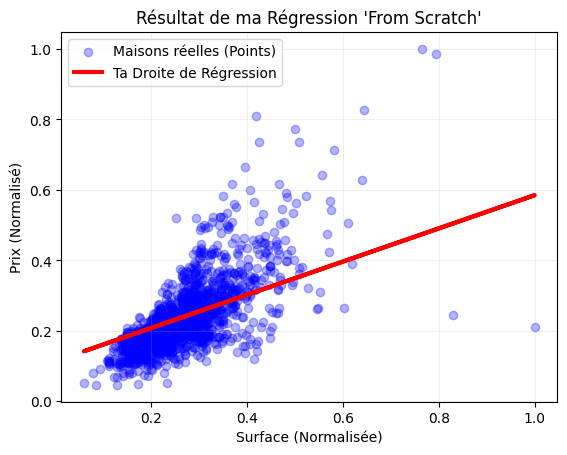

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def RegreL(dataS,a,b,alpha,it=1000):
  history_J = []
  X=dataS[:,0] #pour prend tous les ligne de premier colone
  Y=dataS[:,1] # pour prend tous les ligne de 2eme colone
  m=len(Y)
  x_max = np.max(X)
  y_max = np.max(Y)
  # On divise par le maximum pour que toutes les valeurs soient entre 0 et 1
  X_=X/np.max(X)
  Y_=Y/np.max(Y)
  for i in range(it):
    #On calcul de la prediction
    Yp=a*X_ +b
    #On calcul le cout J MSE
    cost = (1 / (2 * m)) * np.sum((Yp - Y_)**2)
    history_J.append(cost)
    #on calcule le derive partiale de a et b
    deriv_a= (1/m) * np.sum((Yp - Y_) * X_)
    deriv_b= (1/m) * np.sum(Yp - Y_)

    a=a-alpha * deriv_a
    b=b-alpha * deriv_b

  return a,b, history_J, x_max,y_max
#ici j ai importer une dataSet d apres KAGGLE et On charge le fichier directement dans une matrice de chiffres ou on choisi les colone que je vais utilise
dataset = np.genfromtxt('train.csv', delimiter=',', skip_header=1, usecols=(46, 80))
#appel de la fonction Regression
a_fin, b_fin, erreurs, mx, my = RegreL(dataset, 0.0, 0.0, 0.1)

X_plot = dataset[:, 0] / mx
Y_plot = dataset[:, 1] / my
plt.scatter(X_plot, Y_plot, color='blue', alpha=0.3, label='Maisons réelles (Points)')
Y_predite = a_fin * X_plot + b_fin
plt.plot(X_plot, Y_predite, color='red', linewidth=3, label='Ta Droite de Régression')
plt.title("Résultat de ma Régression 'From Scratch'")
plt.xlabel("Surface (Normalisée)")
plt.ylabel("Prix (Normalisé)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()



# Analyse : regression_sklearn_esserdaoui.py

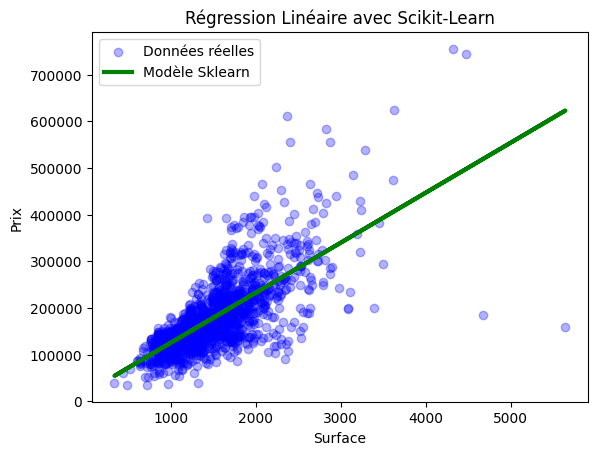

Coefficient (a): 107.1303589658252
Interception (b): 18569.02585648722


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

dataset = np.genfromtxt('train.csv',delimiter=',', skip_header=1, usecols=(46, 80))
X=dataset[:,0].reshape(-1,1)
Y=dataset[:,1]
  #Creation d une instance de l objet LinearRegression
model = LinearRegression()
  #on utilisant l'algorithme des Moindres Carrés Ordinaires la méthode fit prend les donner d entrer et les resultat attendus pour apprendre la relation mathématique qui les lie.
model.fit(X, Y)

y_pred = model.predict(X)

  #Affichage des resultats
plt.scatter(X, Y, color='blue', alpha=0.3, label='Données réelles')
plt.plot(X, y_pred, color='green', linewidth=3, label='Modèle Sklearn')
plt.title("Régression Linéaire avec Scikit-Learn")
plt.xlabel("Surface")
plt.ylabel("Prix")
plt.legend()
plt.show()

print(f"Coefficient (a): {model.coef_[0]}")
print(f"Interception (b): {model.intercept_}")


# Analyse : regression_Multiple_esserdaoui.py

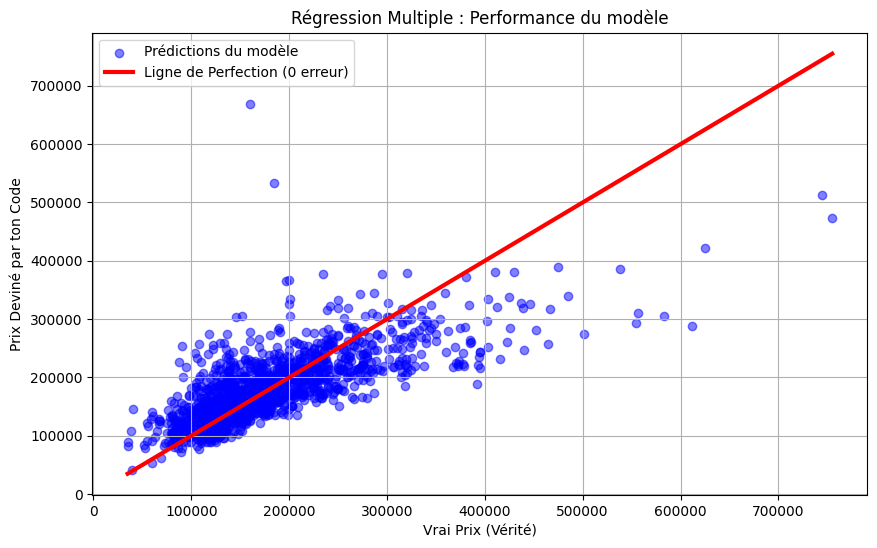

In [4]:
import numpy as np
import matplotlib.pyplot as plt

dataset = np.genfromtxt('train.csv', delimiter=',', skip_header=1, usecols=(46, 47, 48, 80))
X = dataset[:, :-1] # On essaie de stocker toutes les colonnes sauf la dernière (le prix)
y = dataset[:, -1].reshape(-1, 1)# On stocke les valeurs de prix dans une liste d une colonne
m=len(y)
X_b = np.c_[np.ones((m, 1)), X] #On ajoute une colonne de 1 devant la matrice X
XT = X_b.T #On calcule la transposée de la matrice
XR=XT.dot(X_b) # On calcule la multiplication matricielle entre la matrice et sa transposée
X_inv= np.linalg.inv(XR) #Ici on essaie de trouver l'inverse de la matrice
X_Y=XT.dot(y)
W=X_inv.dot(X_Y) # On calcule les coefficients finaux

y_pred = X_b.dot(W) #On calcule les prix devinés
erreur = y_pred - y
mse = (1 / (2 * m)) * np.sum(erreur**2)

#----------------------Visualisation--------------------
plt.figure(figsize=(10, 6))
plt.scatter(y, y_pred, color='blue', alpha=0.5, label='Prédictions du modèle')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linewidth=3, label='Ligne de Perfection (0 erreur)')
plt.xlabel("Vrai Prix (Vérité)")
plt.ylabel("Prix Deviné par ton Code")
plt.title("Régression Multiple : Performance du modèle")
plt.legend()
plt.grid(True)
plt.show()


# Analyse : regression_Multiple_Sklearn_esserdaoui.py

Valeur de départ (b) : 6127.343650333409
Coefficients (a1, a2, a3) : [  106.11917683 31638.76199138  8982.18061516]
Erreur moyenne (MSE) : 2876579007.165129


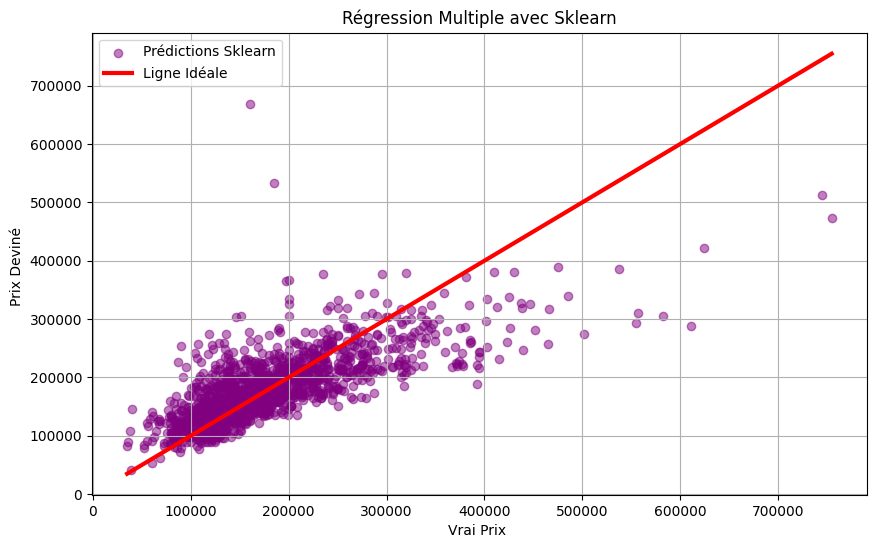

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

#On charge les données avec genfromtxt
dataset = np.genfromtxt('train.csv', delimiter=',', skip_header=1, usecols=(46, 47, 48, 80))

#On sépare les caractéristiques (X) et le prix (y)
X = dataset[:, :-1] # On stocke toutes les colonnes sauf le prix
y = dataset[:, -1]  # On stocke les valeurs de prix (Sklearn accepte les vecteurs plats)

#On crée l'outil de régression (l'objet modèle)
model = LinearRegression()

#On entraîne le modèle (Calcul automatique des coefficients)
model.fit(X, y)

#On demande au modèle de faire des prédictions sur nos données
y_pred = model.predict(X)

#On affiche les résultats trouvés par la bibliothèque
print(f"Valeur de départ (b) : {model.intercept_}")
print(f"Coefficients (a1, a2, a3) : {model.coef_}")

#On calcule l'erreur avec la fonction de la bibliothèque
mse = mean_squared_error(y, y_pred)
print(f"Erreur moyenne (MSE) : {mse}")

# ---------------------- Visualisation --------------------
plt.figure(figsize=(10, 6))
plt.scatter(y, y_pred, color='purple', alpha=0.5, label='Prédictions Sklearn')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linewidth=3, label='Ligne Idéale')
plt.xlabel("Vrai Prix ")
plt.ylabel("Prix Deviné ")
plt.title("Régression Multiple avec Sklearn")
plt.legend()
plt.grid(True)
plt.show()


# Analyse : regression_Poly_esserdaoui.py

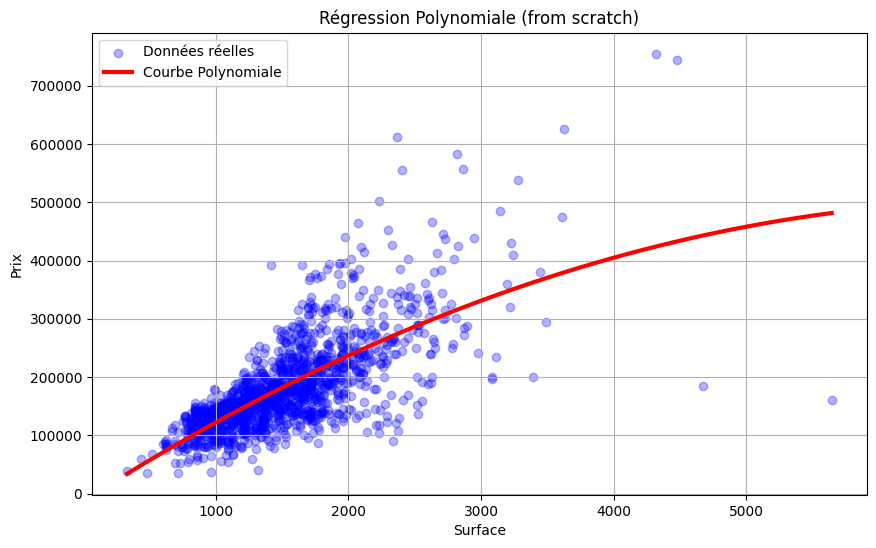

In [6]:
import numpy as np
import matplotlib.pyplot as plt

#On charge les données (Surface et Prix)
dataset = np.genfromtxt('train.csv', delimiter=',', skip_header=1, usecols=(46, 80))

X_single = dataset[:, 0].reshape(-1, 1) # On stocke la colonne de surface
y = dataset[:, 1].reshape(-1, 1)        # On stocke les valeurs de prix

#On crée une matrice avec X et X au carré (X^2)
X_poly = np.c_[X_single, X_single**2]

m = len(y)

#On ajoute une colonne de 1 devant la matrice pour la valeur de départ
X_b = np.c_[np.ones((m, 1)), X_poly]

XT = X_b.T
#On calcule la transposée de la matrice

XR = XT.dot(X_b)
#On calcule la multiplication matricielle entre la matrice et sa transposée

X_inv = np.linalg.inv(XR)
#Ici on essaye de trouver l'inverse de la matrice

X_Y = XT.dot(y)

W = X_inv.dot(X_Y)
#On calcule les coefficients finaux

# --------------- Visualisation-------------------
plt.figure(figsize=(10, 6))
plt.scatter(X_single, y, color='blue', alpha=0.3, label='Données réelles')
x_line = np.linspace(X_single.min(), X_single.max(), 100).reshape(-1, 1)
x_line_b = np.c_[np.ones((100, 1)), x_line, x_line**2]
y_line = x_line_b.dot(W)
plt.plot(x_line, y_line, color='red', linewidth=3, label='Courbe Polynomiale')
plt.xlabel("Surface")
plt.ylabel("Prix")
plt.title("Régression Polynomiale (from scratch)")
plt.legend()
plt.grid(True)
plt.show()


# Analyse : regression_Poly_Sklearn_esserdaoui.py

Erreur Moyenne (MSE) avec Sklearn : 3099756049.468073


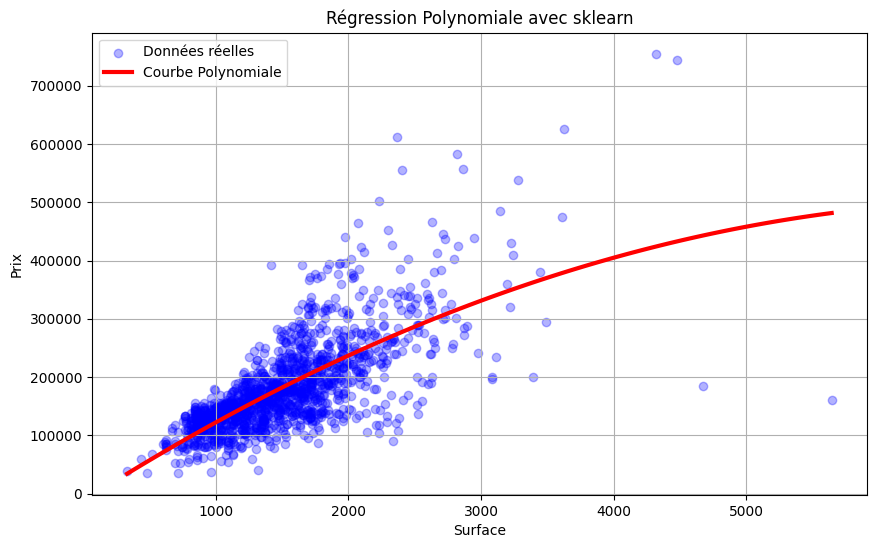

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

#On charge les données
dataset = np.genfromtxt('train.csv', delimiter=',', skip_header=1, usecols=(46, 80))

X = dataset[:, 0].reshape(-1, 1) # On stocke la colonne de surface
y = dataset[:, 1]               # On stocke les valeurs de prix

#Cet outil va créer lui-même les colonnes X et X^2
poly_transformer = PolynomialFeatures(degree=2)
X_poly = poly_transformer.fit_transform(X)

#On crée et on entraîne le modèle de régression
model = LinearRegression()
model.fit(X_poly, y)

#On demande au modèle de faire des prédictions
y_pred = model.predict(X_poly)

#On calcule l'erreur (MSE)
mse = mean_squared_error(y, y_pred)
print(f"Erreur Moyenne (MSE) avec Sklearn : {mse}")

# ----------------Visualisation ------------------
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', alpha=0.3, label='Données réelles')
x_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
x_range_poly = poly_transformer.transform(x_range)
y_curve = model.predict(x_range_poly)
plt.plot(x_range, y_curve, color='red', linewidth=3, label='Courbe Polynomiale')
plt.xlabel("Surface")
plt.ylabel("Prix")
plt.title("Régression Polynomiale avec sklearn")
plt.legend()
plt.grid(True)
plt.show()
